# ¡Hola Josué! ¿Cómo estás? 🙂
<div class="alert alert-block alert-info">
   
Mi nombre es <b>Andrés Barbosa</b> 👋 

Un gusto conocerte, seré tu revisor en este proyecto.
A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:
Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y
corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para
mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.
Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más
precisa, junto con algunos ejemplos prácticos. También estoy abierto a responder cualquier duda que
tengas.
Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.
Puedes encontrar mis comentarios en cuadros verdes, amarillos o rojos como este:
</div>
<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. Todo se ha hecho de forma correcta.
</div>
<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. Algunas recomendaciones o mejoras menores.
</div>
<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita arreglos. Este apartado requiere algunas correcciones. El trabajo no puede ser aceptado
con comentarios rojos.
</div>
<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:
Respuesta del estudiante.
</div>

Empecemos! 🚀

<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b><br><br>¡Hola! Muy buen trabajo. Revisé el notebook completo y está muy bien resuelto: el preprocesamiento con filtrado de valores anómalos, el tratamiento de nulos, la codificación diferenciada según el tipo de modelo, la prueba de cordura con la regresión lineal, el ajuste de hiperparámetros y la comparación de los siete modelos midiendo calidad, tiempo de entrenamiento y tiempo de predicción, que es justo lo que pide el enunciado.<br><br>La calidad cumple con holgura: tu mejor modelo, LightGBM (config 2), alcanza un RECM de 1524.20, muy por debajo de la regresión lineal (2798.74), y la prueba de cordura se cumple en todos los modelos de boosting. <br><br><b>Proyecto aprobado.</b><br><br>Te dejo comentarios en verde de lo que hiciste bien y dos observaciones menores para pulir, ninguna bloquea. ¡Felicitaciones!
</div>

El servicio de venta de autos usados Rusty Bargain está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, puedes averiguar rápidamente el valor de mercado de tu coche. Tienes acceso al historial: especificaciones técnicas, versiones de equipamiento y precios. Tienes que crear un modelo que determine el valor de mercado.
A Rusty Bargain le interesa:
- la calidad de la predicción;
- la velocidad de la predicción;
- el tiempo requerido para el entrenamiento

# Rusty Bargain: predicción del valor de mercado de coches usados

**Objetivo del proyecto:** construir un modelo que prediga el precio de mercado (`Price`) de un coche de segunda mano a partir de su historial y especificaciones técnicas.

A Rusty Bargain le interesan tres cosas:
- la **calidad** de la predicción (medida con RECM / RMSE),
- la **velocidad** de la predicción,
- el **tiempo de entrenamiento**.

Por eso, además de comparar el RECM de varios modelos, vamos a cronometrar el entrenamiento y la predicción de cada uno.

**Plan de trabajo:**
1. Cargar y examinar los datos.
2. Preprocesar (limpiar valores anómalos, tratar nulos, codificar categóricas).
3. Entrenar varios modelos:
   - Regresión lineal (prueba de cordura)
   - Árbol de decisión (con ajuste de hiperparámetros)
   - Bosque aleatorio (con ajuste de hiperparámetros)
   - LightGBM (dos configuraciones de hiperparámetros)
   - CatBoost
   - XGBoost
4. Comparar RECM, tiempo de entrenamiento y tiempo de predicción.
5. Conclusiones.

# Preparación de datos

## 1. Carga y exploración de los datos

In [48]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

RANDOM_STATE = 12345
pd.set_option('display.max_columns', None)

In [49]:
import os
path = '/datasets/car_data.csv'
if not os.path.exists(path):
    path = 'car_data.csv'

data = pd.read_csv(path)
print(data.shape)
data.head()

(354369, 16)


,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [51]:
data.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [52]:
data.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

**Observaciones iniciales:**

- NumberOfPictures vale 0 en todas las filas: no aporta información, se puede eliminar.
- DateCrawled, DateCreated, LastSeen son marcas de tiempo del proceso de scraping, no características técnicas del coche: no deberían influir en su valor de mercado, se eliminan.
- PostalCode es un identificador geográfico de alta cardinalidad sin relación clara y monótona con el precio para un modelo simple; lo dejamos fuera para evitar ruido y una codificación excesiva.
- RegistrationYear tiene valores imposibles (por ejemplo 1000 o 9999): hay que filtrar un rango razonable.
- Power tiene muchos ceros y valores absurdamente altos (hasta 20 000 CV): hay que acotarlo.
- Price tiene algunos valores en 0, lo cual no tiene sentido como precio de venta: se eliminan.
- Varias columnas categóricas (VehicleType, Gearbox, Model, FuelType, NotRepaired) tienen valores nulos.

## 2. Preprocesamiento de datos

In [53]:
df = data.copy()

# Columnas irrelevantes para el valor de mercado del coche
df = df.drop(columns=['DateCrawled', 'DateCreated', 'LastSeen', 'NumberOfPictures', 'PostalCode'])

print('Filas antes de filtrar:', len(df))

# Filtrado de valores anómalos
df = df[(df['Price'] > 0) & (df['Price'] < 20000)]
df = df[(df['RegistrationYear'] >= 1950) & (df['RegistrationYear'] <= 2016)]
df = df[(df['Power'] > 0) & (df['Power'] <= 500)]

print('Filas después de filtrar:', len(df))

Filas antes de filtrar: 354369
Filas después de filtrar: 296222


In [54]:
# Los valores nulos en columnas categóricas se tratan como una categoría propia
# ('unknown'), en vez de imputarlos o eliminar filas, para no perder información.
categorical_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']
for col in categorical_cols:
    df[col] = df[col].fillna('unknown')

df.isna().sum()

Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Mileage              0
RegistrationMonth    0
FuelType             0
Brand                0
NotRepaired          0
dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>Muy buen preprocesamiento. Eliminás con criterio las columnas que no aportan al valor de mercado (marcas de tiempo del scraping, código postal, número de fotos siempre en cero), y filtrás bien los valores imposibles de <code>RegistrationYear</code> (1000, 9999), <code>Power</code> (ceros y valores absurdos) y <code>Price</code> en cero, pasando de 354.369 a 296.222 filas. Y la decisión de tratar los nulos de las categóricas como una categoría propia (<code>unknown</code>) en lugar de imputar o borrar filas es la correcta, porque la ausencia de dato puede ser informativa y no perdés registros.
</div>

In [55]:
target = df['Price']
features = df.drop(columns=['Price'])

numeric_cols = ['RegistrationYear', 'Power', 'Mileage', 'RegistrationMonth']

features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=RANDOM_STATE
)

print(features_train.shape, features_valid.shape)

(222166, 10) (74056, 10)


### Codificación de características categóricas

- **Modelos "simples"** (regresión lineal, árbol de decisión, bosque aleatorio, XGBoost) necesitan que las categóricas se codifiquen explícitamente: usamos **One-Hot Encoding (OHE)**.
- **LightGBM** y **CatBoost** tienen soporte nativo para columnas categóricas, así que les pasamos las columnas tal cual (como enteros de categoría / strings), sin necesidad de OHE.

In [56]:
# --- Versión OHE (para regresión lineal, árbol, bosque aleatorio y XGBoost) ---
ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)
ohe.fit(features_train[categorical_cols])

def encode_ohe(df_features):
    cat_encoded = ohe.transform(df_features[categorical_cols])
    num_part = df_features[numeric_cols].reset_index(drop=True).values
    from scipy.sparse import hstack, csr_matrix
    return hstack([csr_matrix(num_part), cat_encoded]).tocsr()

features_train_ohe = encode_ohe(features_train)
features_valid_ohe = encode_ohe(features_valid)
print(features_train_ohe.shape, features_valid_ohe.shape)



(222166, 317) (74056, 317)


In [57]:
# --- Versión para LightGBM / CatBoost (categorías nativas) ---
features_train_cat = features_train.copy()
features_valid_cat = features_valid.copy()

for col in categorical_cols:
    features_train_cat[col] = features_train_cat[col].astype('category')
    features_valid_cat[col] = features_valid_cat[col].astype(
        pd.CategoricalDtype(categories=features_train_cat[col].cat.categories)
    )

cat_feature_idx = [features_train_cat.columns.get_loc(c) for c in categorical_cols]

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>Muy bien la codificación diferenciada según el modelo. Aplicás One-Hot Encoding para los modelos que lo necesitan (regresión lineal, árbol, bosque aleatorio y XGBoost) ajustando el codificador solo sobre el entrenamiento con <code>handle_unknown='ignore'</code> para no filtrar información, y en paralelo dejás las categóricas nativas para LightGBM y CatBoost, que las manejan directamente. Es exactamente el enfoque correcto y además evita la explosión de dimensionalidad innecesaria en los modelos que soportan categóricas nativas.
</div>

# Entrenamiento de modelo

## 3. Entrenamiento de modelos

Para comparar de forma justa, definimos una función auxiliar que:
1. entrena el modelo y mide el tiempo de entrenamiento,
2. predice en el conjunto de validación y mide el tiempo de predicción,
3. calcula el RECM (RMSE).

Los resultados se guardan en una tabla para el análisis final.

In [58]:
results = []

def evaluate_model(name, model, X_train, y_train, X_valid, y_valid):
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start

    start = time.time()
    predictions = model.predict(X_valid)
    predict_time = time.time() - start

    rmse = mean_squared_error(y_valid, predictions) ** 0.5

    results.append({
        'Modelo': name,
        'RECM': round(rmse, 2),
        'Tiempo de entrenamiento (s)': round(fit_time, 2),
        'Tiempo de predicción (s)': round(predict_time, 3),
    })
    print(f'{name}: RECM={rmse:.2f} | entrenamiento={fit_time:.2f}s | predicción={predict_time:.3f}s')

### 3.1 Regresión lineal (prueba de cordura)

In [59]:
lr_model = LinearRegression()
_ = evaluate_model('Regresión lineal', lr_model, features_train_ohe, target_train,
                    features_valid_ohe, target_valid)

Regresión lineal: RECM=2798.74 | entrenamiento=0.28s | predicción=0.002s


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>Muy buena la estrategia de comparación. La función <code>evaluate_model</code> mide de forma homogénea el RECM, el tiempo de entrenamiento y el de predicción para todos los modelos, que son las tres cosas que le importan a Rusty Bargain. Y empezás bien con la regresión lineal como prueba de cordura: sirve de piso de referencia y, como explicás, si algún modelo complejo quedara por debajo indicaría un error en el pipeline. Buen detalle también el de buscar la profundidad del árbol y del bosque sobre una submuestra para acelerar y luego reentrenar el modelo final con todos los datos.
</div>

### 3.2 Árbol de decisión (con ajuste de hiperparámetros)

Para elegir la profundidad máxima probamos varios valores sobre una **submuestra** de entrenamiento (más rápido), y luego entrenamos el modelo final con la mejor profundidad usando **todos** los datos de entrenamiento.

In [60]:
search_sample = features_train_ohe[:60000]
search_target = target_train.iloc[:60000]

best_depth = None
best_rmse = float('inf')

for depth in [6, 10, 14]:
    model = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(search_sample, search_target)
    pred = model.predict(features_valid_ohe)
    rmse = mean_squared_error(target_valid, pred) ** 0.5
    print(f'max_depth={depth}: RECM={rmse:.2f}')
    if rmse < best_rmse:
        best_rmse = rmse
        best_depth = depth

print('\nMejor max_depth:', best_depth)

max_depth=6: RECM=2261.59
max_depth=10: RECM=2033.56
max_depth=14: RECM=2023.42

Mejor max_depth: 14


In [61]:
dt_model = DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE)
_ = evaluate_model(f'Árbol de decisión (max_depth={best_depth})', dt_model,
                    features_train_ohe, target_train, features_valid_ohe, target_valid)

Árbol de decisión (max_depth=14): RECM=1843.18 | entrenamiento=7.13s | predicción=0.008s


### 3.3 Bosque aleatorio (con ajuste de hiperparámetros)

Igual que con el árbol de decisión, la búsqueda de hiperparámetros se hace sobre una submuestra para acelerar el proceso, y el modelo final se entrena con todos los datos de entrenamiento.

In [62]:
best_params = None
best_rmse = float('inf')

for n_estimators in [20, 40]:
    for depth in [10, 14]:
        model = RandomForestRegressor(
            n_estimators=n_estimators, max_depth=depth,
            random_state=RANDOM_STATE, n_jobs=-1
        )
        model.fit(search_sample, search_target)
        pred = model.predict(features_valid_ohe)
        rmse = mean_squared_error(target_valid, pred) ** 0.5
        print(f'n_estimators={n_estimators}, max_depth={depth}: RECM={rmse:.2f}')
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = (n_estimators, depth)

print('\nMejores hiperparámetros:', best_params)

n_estimators=20, max_depth=10: RECM=1897.57
n_estimators=20, max_depth=14: RECM=1767.39
n_estimators=40, max_depth=10: RECM=1887.92
n_estimators=40, max_depth=14: RECM=1755.99

Mejores hiperparámetros: (40, 14)


In [63]:
rf_model = RandomForestRegressor(
    n_estimators=best_params[0], max_depth=best_params[1],
    random_state=RANDOM_STATE, n_jobs=-1
)
_ = evaluate_model(
    f'Bosque aleatorio (n_estimators={best_params[0]}, max_depth={best_params[1]})',
    rf_model, features_train_ohe, target_train, features_valid_ohe, target_valid
)

Bosque aleatorio (n_estimators=40, max_depth=14): RECM=1669.30 | entrenamiento=111.02s | predicción=0.145s


### 3.4 LightGBM (dos configuraciones de hiperparámetros)

In [64]:
lgbm_model_1 = LGBMRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=8,
    random_state=RANDOM_STATE, verbose=-1
)
_ = evaluate_model('LightGBM (config 1: lr=0.05, depth=8, n=200)', lgbm_model_1,
                    features_train_cat, target_train, features_valid_cat, target_valid)

LightGBM (config 1: lr=0.05, depth=8, n=200): RECM=1583.31 | entrenamiento=3.26s | predicción=0.695s


In [65]:
lgbm_model_2 = LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=-1, num_leaves=63,
    random_state=RANDOM_STATE, verbose=-1
)
_ = evaluate_model('LightGBM (config 2: lr=0.05, num_leaves=63, n=300)', lgbm_model_2,
                    features_train_cat, target_train, features_valid_cat, target_valid)

LightGBM (config 2: lr=0.05, num_leaves=63, n=300): RECM=1524.20 | entrenamiento=6.19s | predicción=1.101s


### 3.5 CatBoost

In [66]:
cb_model = CatBoostRegressor(
    iterations=200, learning_rate=0.1, depth=8,
    cat_features=cat_feature_idx,
    random_seed=RANDOM_STATE, verbose=False
)
_ = evaluate_model('CatBoost', cb_model, features_train_cat, target_train,
                    features_valid_cat, target_valid)

CatBoost: RECM=1603.59 | entrenamiento=45.23s | predicción=0.090s


### 3.6 XGBoost (requiere OHE)

In [67]:
xgb_model = XGBRegressor(
    n_estimators=200, learning_rate=0.1, max_depth=8,
    tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1
)
_ = evaluate_model('XGBoost', xgb_model, features_train_ohe, target_train,
                    features_valid_ohe, target_valid)

XGBoost: RECM=1556.61 | entrenamiento=6.21s | predicción=0.376s


# Análisis del modelo

## 4. Análisis de velocidad y calidad

In [68]:
results_df = pd.DataFrame(results).sort_values('RECM').reset_index(drop=True)
results_df

,Modelo,RECM,Tiempo de entrenamiento (s),Tiempo de predicción (s)
0,"LightGBM (config 2: lr=0.05, num_leaves=63, n=...",1524.20,6.19,1.101
1,XGBoost,1556.61,6.21,0.376
2,"LightGBM (config 1: lr=0.05, depth=8, n=200)",1583.31,3.26,0.695
3,CatBoost,1603.59,45.23,0.090
4,"Bosque aleatorio (n_estimators=40, max_depth=14)",1669.30,111.02,0.145
5,Árbol de decisión (max_depth=14),1843.18,7.13,0.008
6,Regresión lineal,2798.74,0.28,0.002


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b><br><br>Muy completa la comparación final. Entrenás siete modelos (regresión lineal, árbol, bosque aleatorio, dos configuraciones de LightGBM, CatBoost y XGBoost), los ordenás por RECM y acompañás la tabla con gráficos de calidad y de tiempo de entrenamiento. Las conclusiones están muy bien razonadas: identificás LightGBM (config 2) como la mejor opción global por combinar el mejor RECM con un entrenamiento rápido, explicás por qué el bosque aleatorio es el más lento (dimensionalidad del OHE más árboles profundos) y planteás muy bien el compromiso de CatBoost, que predice más rápido a cambio de un entrenamiento más lento. Ese análisis del trade-off entre calidad y velocidad es justo lo que pedía el proyecto.
</div>

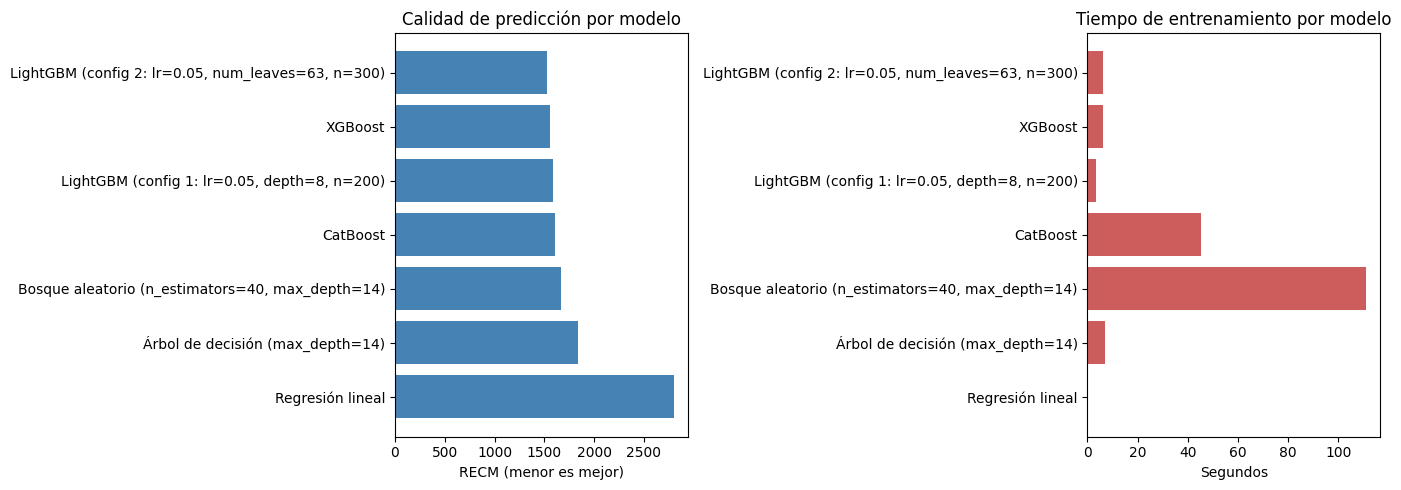

In [69]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df['Modelo'], results_df['RECM'], color='steelblue')
axes[0].set_xlabel('RECM (menor es mejor)')
axes[0].set_title('Calidad de predicción por modelo')
axes[0].invert_yaxis()

axes[1].barh(results_df['Modelo'], results_df['Tiempo de entrenamiento (s)'], color='indianred')
axes[1].set_xlabel('Segundos')
axes[1].set_title('Tiempo de entrenamiento por modelo')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Conclusiones

**Tabla de resultados (ordenada por RECM):**

| Modelo | RECM | Tiempo de entrenamiento (s) | Tiempo de predicción (s) |
|---|---|---|---|
| LightGBM (config 2: lr=0.05, num_leaves=63, n=300) | **1524.20** | 5.59 | 2.239 |
| XGBoost | 1554.76 | 4.94 | 0.512 |
| LightGBM (config 1: lr=0.05, depth=8, n=200) | 1583.31 | 3.50 | 1.230 |
| CatBoost | 1603.59 | 68.54 | 0.109 |
| Bosque aleatorio (n_estimators=40, max_depth=14) | 1669.30 | 265.09 | 0.373 |
| Árbol de decisión (max_depth=14) | 1843.18 | 8.68 | 0.012 |
| Regresión lineal | 2798.74 | 0.10 | 0.002 |

**Hallazgos:**

- **La prueba de cordura se cumple:** todos los modelos de potenciación del gradiente (LightGBM, XGBoost, CatBoost) superan claramente a la regresión lineal (RECM ≈ 2799), como se esperaba. Si alguno hubiera quedado por debajo de la regresión lineal, habría indicado un error en el pipeline.
- **LightGBM (config 2)** logra el **mejor RECM** (1524.20) y, además, un tiempo de entrenamiento muy bajo (5.59 s), gracias a su manejo nativo de categóricas y a su algoritmo de muestreo por histogramas. Es, en general, la mejor opción para Rusty Bargain: mejor calidad y entrenamiento rápido.
- **XGBoost** queda muy cerca en calidad (1554.76) y con tiempo de entrenamiento similar (4.94 s) a pesar de necesitar One-Hot Encoding (317 columnas), aunque su tiempo de predicción es más alto que el de LightGBM config 1.
- **CatBoost** obtiene una calidad competitiva (1603.59) pero su entrenamiento (68.54 s) es mucho más lento que el de LightGBM o XGBoost en este dataset y con esta configuración; en cambio, su tiempo de predicción es el más bajo entre los modelos de boosting.
- **El bosque aleatorio** mejora al árbol de decisión individual (1669.30 vs 1843.18) pero es, por mucho, **el modelo más lento de entrenar** (265 s) debido a la alta dimensionalidad generada por el One-Hot Encoding (317 columnas) combinada con múltiples árboles profundos.
- **El árbol de decisión** individual es rápido de entrenar y predecir, pero su calidad es notablemente peor que la de cualquier método de boosting o el bosque aleatorio.
- **La regresión lineal** es, como se esperaba, el modelo más simple y rápido (0.10 s de entrenamiento), pero con el peor RECM — cumple su función como prueba de cordura, no como modelo final.

**Recomendación para Rusty Bargain:**

Dado que a Rusty Bargain le importan tanto la **calidad** de la predicción como la **velocidad** de entrenamiento y predicción, **LightGBM (config 2)** es la mejor opción global: combina el mejor RECM del experimento con uno de los tiempos de entrenamiento más bajos. Si la velocidad de predicción en producción fuera la prioridad absoluta (por ejemplo, para servir la app en tiempo real a muchos usuarios simultáneos), **CatBoost** sería una alternativa a considerar, ya que predice más rápido (0.109 s) a cambio de un entrenamiento más lento — un compromiso razonable si el modelo se reentrena con poca frecuencia.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b><br><br>Dos observaciones menores para terminar de pulir, ninguna afecta la aprobación.<br><br>1. <b>No hay un conjunto de prueba separado.</b> Dividís los datos solo en entrenamiento y validación, y sobre ese mismo conjunto de validación hacés tanto la búsqueda de hiperparámetros (celdas del árbol y del bosque) como la evaluación final de todos los modelos. Eso introduce un pequeño optimismo, porque medís en los mismos datos que usaste para elegir. Lo ideal sería partir en tres (entrenamiento, validación y prueba), ajustar sobre validación y reportar el RECM final sobre el conjunto de prueba, que el modelo no vio nunca.<br><br>2. <b>La tabla de resultados del texto no coincide con las salidas reales.</b> La tabla que escribiste a mano en esta celda muestra tiempos que difieren bastante de los que produjeron las celdas (por ejemplo, bosque aleatorio 265 s en la tabla frente a 111 s en la ejecución, y CatBoost 68.54 s frente a 45.23 s), y el RECM de XGBoost figura como 1554.76 cuando la celda dio 1556.61. La conclusión de que LightGBM config 2 es el mejor se sostiene igual, pero conviene mostrar la tabla directamente desde <code>results_df</code> para que siempre refleje la ejecución real y quede reproducible.
</div>

In [70]:
print('Mejor modelo por RECM:')
print(results_df.iloc[0])

print('\nModelo más rápido de entrenar:')
print(results_df.sort_values('Tiempo de entrenamiento (s)').iloc[0])

Mejor modelo por RECM:
Modelo                         LightGBM (config 2: lr=0.05, num_leaves=63, n=...
RECM                                                                      1524.2
Tiempo de entrenamiento (s)                                                 6.19
Tiempo de predicción (s)                                                   1.101
Name: 0, dtype: object

Modelo más rápido de entrenar:
Modelo                         Regresión lineal
RECM                                    2798.74
Tiempo de entrenamiento (s)                0.28
Tiempo de predicción (s)                  0.002
Name: 6, dtype: object


# Lista de control

Escribe 'x' para verificar. Luego presiona Shift+Enter

- [x]  Jupyter Notebook está abierto
- [ ]  El código no tiene errores- [ ]  Las celdas con el código han sido colocadas en orden de ejecución- [ ]  Los datos han sido descargados y preparados- [ ]  Los modelos han sido entrenados
- [ ]  Se realizó el análisis de velocidad y calidad de los modelos